In [1]:
import os
import random
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.categorical import Categorical

In [ ]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class Agent(nn.Module):
    def __init__(self, envs):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(np.array(envs.single_observation_space.shape).prod(), 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 1), std=1.0),
        )
        self.actor = nn.Sequential(
            layer_init(nn.Linear(np.array(envs.single_observation_space.shape).prod(), 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, envs.single_action_space.n), std=0.01),
        )

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        logits = self.actor(x)
        probs = Categorical(logits=logits)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action), probs.entropy(), self.critic(x)

In [3]:
def make_env(env_id):
    def thunk():
        env = gym.make(env_id)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        return env
    return thunk

In [4]:
seed = 42
env_id = "CartPole-v1"
num_envs = 4
learning_rate = 2.5e-4
num_steps = 128
num_iterations = 1000
anneal_lr = True
gamma = 0.99
gae_lambda = 0.95
num_minibatches = 4
update_epochs = 4
norm_adv = True
clip_coef = 0.2
clip_vloss = True
ent_coef = 0.01
vf_coef = 0.5
max_grad_norm = 0.5
target_kl = None

batch_size = num_envs * num_steps
minibatch_size = batch_size // num_minibatches
plot_smoothing_window = 20


In [5]:
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

envs = gym.vector.SyncVectorEnv(
    [make_env(env_id) for i in range(num_envs)],
)

agent = Agent(envs).to(device)
optimizer = optim.Adam(agent.parameters(), lr = learning_rate, eps=1e-5)


# ALGO Logic: Storage setup
# save the observation of each steps
obs = torch.zeros((num_steps, num_envs) + envs.single_observation_space.shape).to(device)
# save the action of each steps that the agent takes
actions = torch.zeros((num_steps, num_envs) + envs.single_action_space.shape).to(device)
# save the log probability of each action that the agent takes
logprobs = torch.zeros((num_steps, num_envs)).to(device)
# the reward received after taking the action
rewards = torch.zeros((num_steps, num_envs)).to(device)
# whether the episode is done after taking the action
dones = torch.zeros((num_steps, num_envs)).to(device)
# save the value that the critic estimates for each step
values = torch.zeros((num_steps, num_envs)).to(device)

global_step = 0
start_time = time.time()
next_obs, _ = envs.reset(seed = seed)
next_obs = torch.Tensor(next_obs).to(device)
next_done = torch.zeros(num_envs).to(device)

episode_steps = []
episode_returns = []
episode_lengths = []
training_log = {
    "global_step": [],
    "learning_rate": [],
    "value_loss": [],
    "policy_loss": [],
    "entropy": [],
    "old_approx_kl": [],
    "approx_kl": [],
    "clipfrac": [],
    "explained_variance": [],
    "SPS": [],
}
print_every = max(1, num_iterations // 20)

for iteration in range(1, num_iterations +1):
    if anneal_lr:
        frac = 1 - (iteration - 1) / num_iterations
        lrnow = frac * learning_rate
        optimizer.param_groups[0]['lr'] = lrnow
    
    for step in range(0, num_steps):    
        global_step += 1 * num_envs
        obs[step] = next_obs
        dones[step] = next_done

        with torch.no_grad():
            action, logprob, _, value = agent.get_action_and_value(next_obs)
            values[step] = value.flatten()
        actions[step] = action
        logprobs[step] = logprob

        
        # TRY NOT TO MODIFY: execute the game and log data.
        next_obs, reward, terminations, truncations, infos = envs.step(action.cpu().numpy())
        next_done = np.logical_or(terminations, truncations)
        rewards[step] = torch.tensor(reward).to(device).view(-1)
        next_obs, next_done = torch.Tensor(next_obs).to(device), torch.Tensor(next_done).to(device)

        if "final_info" in infos:
            for info in infos["final_info"]:
                if info and "episode" in info:
                    episode_steps.append(global_step)
                    episode_returns.append(float(np.asarray(info["episode"]["r"]).item()))
                    episode_lengths.append(int(np.asarray(info["episode"]["l"]).item()))
        elif "episode" in infos:
            episode_mask = infos.get("_episode", np.ones(num_envs, dtype=bool))
            for episodic_return, episodic_length in zip(
                infos["episode"]["r"][episode_mask],
                infos["episode"]["l"][episode_mask],
            ):
                episode_steps.append(global_step)
                episode_returns.append(float(episodic_return))
                episode_lengths.append(int(episodic_length))

    # bootstrap value if not done
    with torch.no_grad():
        next_value = agent.get_value(next_obs).reshape(1, -1)
        advantages = torch.zeros_like(rewards).to(device)
        lastgaelam = 0
        for t in reversed(range(num_steps)):
            if t == num_steps - 1:
                nextnonterminal = 1.0 - next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - dones[t + 1]
                nextvalues = values[t + 1]
            delta = rewards[t] + gamma * nextvalues * nextnonterminal - values[t]
            advantages[t] = lastgaelam = delta + gamma * gae_lambda * nextnonterminal * lastgaelam
        returns = advantages + values

    # flatten the batch
    b_obs = obs.reshape((-1,) + envs.single_observation_space.shape)
    b_logprobs = logprobs.reshape(-1)
    b_actions = actions.reshape((-1,) + envs.single_action_space.shape)
    b_advantages = advantages.reshape(-1)
    b_returns = returns.reshape(-1)
    b_values = values.reshape(-1)     

    # Optimizing the policy and value network
    b_inds = np.arange(batch_size)
    clipfracs = []
    for epoch in range(update_epochs):
        np.random.shuffle(b_inds)
        for start in range(0, batch_size, minibatch_size):
            end = start + minibatch_size
            mb_inds = b_inds[start:end]

            _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb_inds], b_actions.long()[mb_inds])
            logratio = newlogprob - b_logprobs[mb_inds]
            ratio = logratio.exp()

            with torch.no_grad():
                # calculate approx_kl http://joschu.net/blog/kl-approx.html
                old_approx_kl = (-logratio).mean()
                approx_kl = ((ratio - 1) - logratio).mean()
                clipfracs += [((ratio - 1.0).abs() > clip_coef).float().mean().item()]

            mb_advantages = b_advantages[mb_inds]
            if norm_adv:
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

            # Policy loss
            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()

            # Value loss
            newvalue = newvalue.view(-1)
            if clip_vloss:
                v_loss_unclipped = (newvalue - b_returns[mb_inds]) ** 2
                v_clipped = b_values[mb_inds] + torch.clamp(
                    newvalue - b_values[mb_inds],
                    -clip_coef,
                    clip_coef,
                )
                v_loss_clipped = (v_clipped - b_returns[mb_inds]) ** 2
                v_loss_max = torch.max(v_loss_unclipped, v_loss_clipped)
                v_loss = 0.5 * v_loss_max.mean()
            else:
                v_loss = 0.5 * ((newvalue - b_returns[mb_inds]) ** 2).mean()

            entropy_loss = entropy.mean()
            loss = pg_loss - ent_coef * entropy_loss + v_loss * vf_coef

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()

        if target_kl is not None and approx_kl > target_kl:
            break

    y_pred, y_true = b_values.detach().cpu().numpy(), b_returns.detach().cpu().numpy()
    var_y = np.var(y_true)
    explained_var = np.nan if var_y == 0 else 1 - np.var(y_true - y_pred) / var_y
    sps = int(global_step / (time.time() - start_time))

    training_log["global_step"].append(global_step)
    training_log["learning_rate"].append(optimizer.param_groups[0]["lr"])
    training_log["value_loss"].append(v_loss.item())
    training_log["policy_loss"].append(pg_loss.item())
    training_log["entropy"].append(entropy_loss.item())
    training_log["old_approx_kl"].append(old_approx_kl.item())
    training_log["approx_kl"].append(approx_kl.item())
    training_log["clipfrac"].append(float(np.mean(clipfracs)))
    training_log["explained_variance"].append(float(explained_var))
    training_log["SPS"].append(sps)

    if iteration == 1 or iteration % print_every == 0:
        recent_return = np.mean(episode_returns[-10:]) if episode_returns else np.nan
        print(
            f"iteration={iteration}/{num_iterations}, "
            f"global_step={global_step}, "
            f"mean_return_10={recent_return:.1f}, "
            f"SPS={sps}"
        )

envs.close()


Using device: cuda
iteration=1/1000, global_step=512, mean_return_10=25.1, SPS=732
iteration=50/1000, global_step=25600, mean_return_10=220.3, SPS=4463
iteration=100/1000, global_step=51200, mean_return_10=228.5, SPS=4514
iteration=150/1000, global_step=76800, mean_return_10=201.9, SPS=4524
iteration=200/1000, global_step=102400, mean_return_10=454.1, SPS=4548
iteration=250/1000, global_step=128000, mean_return_10=389.6, SPS=4564
iteration=300/1000, global_step=153600, mean_return_10=255.3, SPS=4608
iteration=350/1000, global_step=179200, mean_return_10=214.0, SPS=4671
iteration=400/1000, global_step=204800, mean_return_10=464.6, SPS=4758
iteration=450/1000, global_step=230400, mean_return_10=369.7, SPS=4832
iteration=500/1000, global_step=256000, mean_return_10=482.5, SPS=4895
iteration=550/1000, global_step=281600, mean_return_10=500.0, SPS=4948
iteration=600/1000, global_step=307200, mean_return_10=500.0, SPS=4988
iteration=650/1000, global_step=332800, mean_return_10=500.0, SPS=502

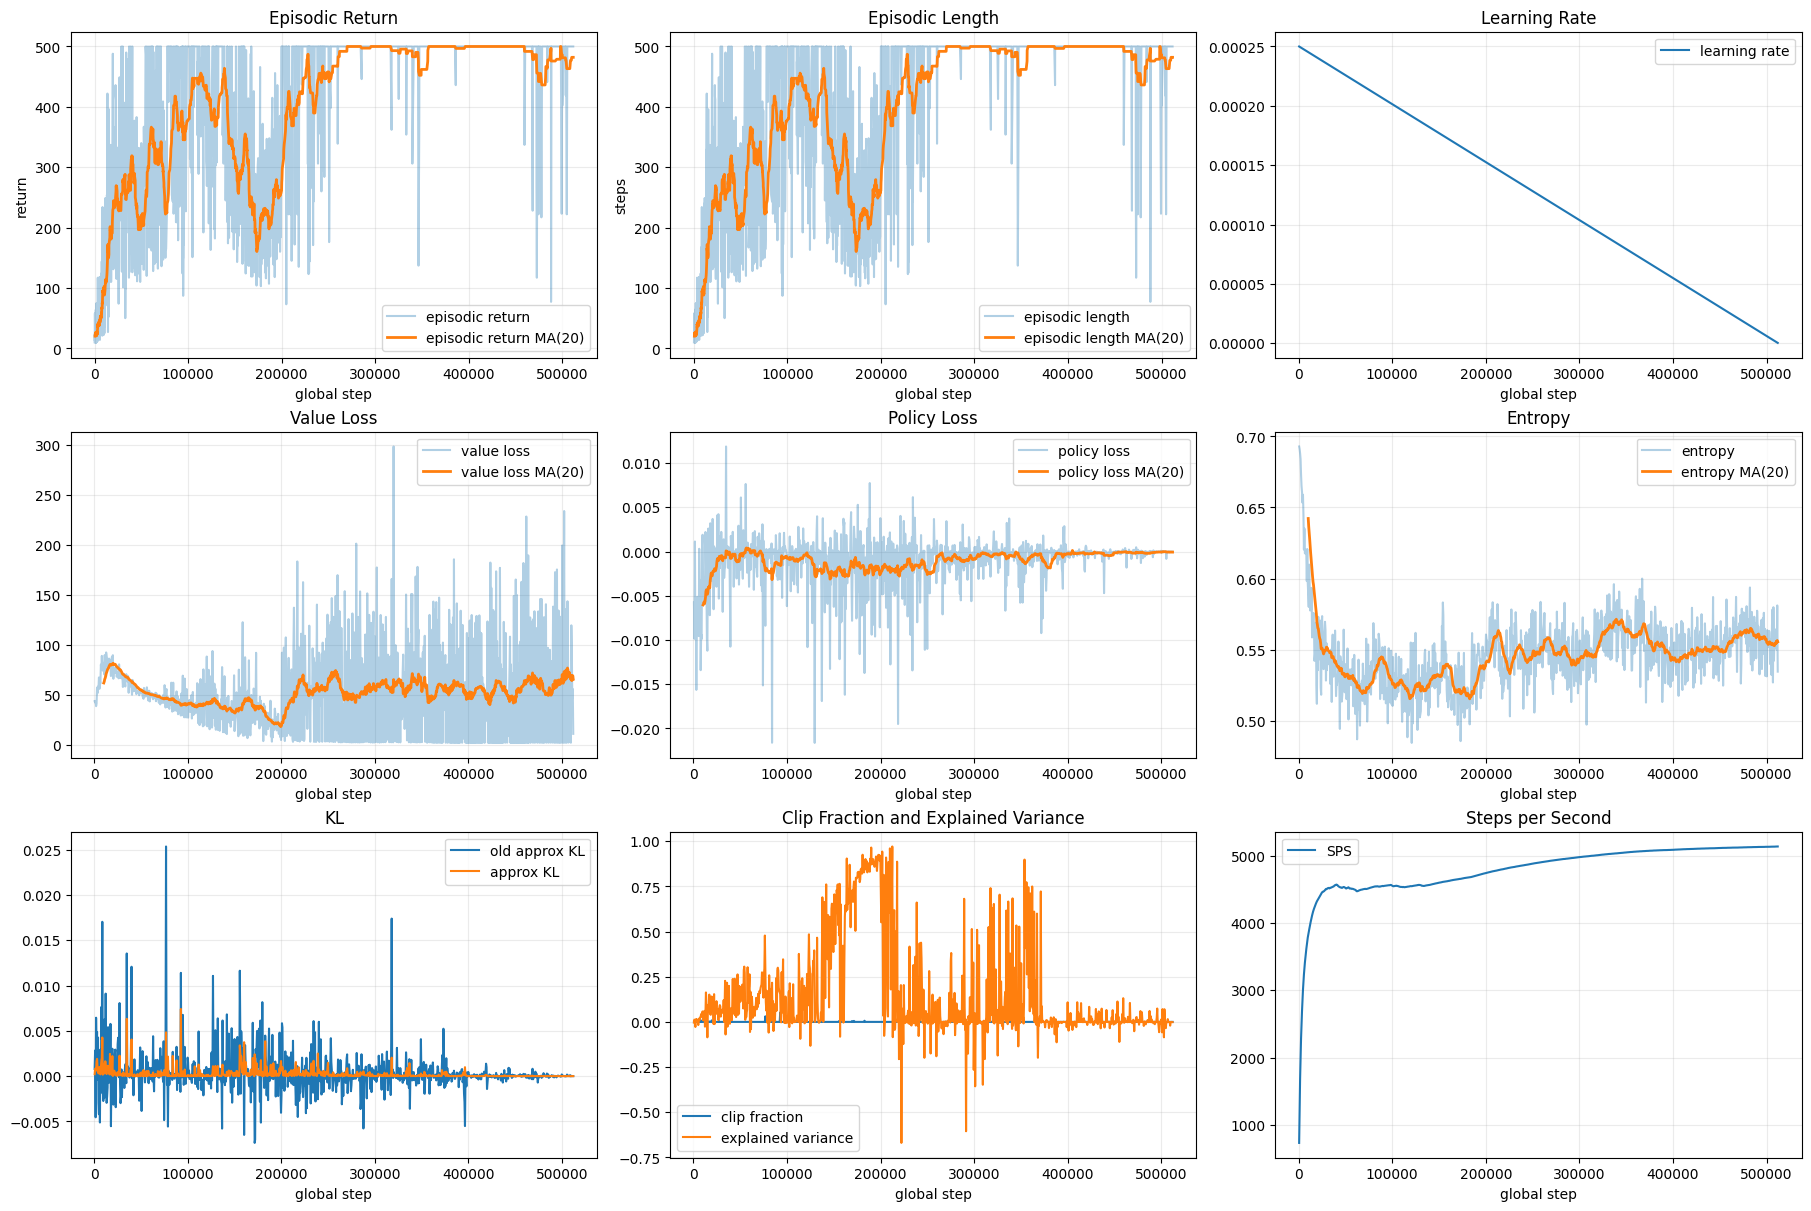

In [6]:
def moving_average(values, window):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return values, 0
    window = max(1, min(window, len(values)))
    if window == 1:
        return values, window
    weights = np.ones(window) / window
    return np.convolve(values, weights, mode="valid"), window


def plot_smoothed(ax, x, y, label, window=plot_smoothing_window):
    x = np.asarray(x)
    y = np.asarray(y, dtype=float)
    if len(y) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        return
    ax.plot(x, y, alpha=0.35, label=label)
    y_smooth, used_window = moving_average(y, window)
    if used_window > 1:
        ax.plot(x[used_window - 1 :], y_smooth, linewidth=2, label=f"{label} MA({used_window})")
    ax.legend()


steps = training_log["global_step"]
fig, axes = plt.subplots(3, 3, figsize=(18, 12), constrained_layout=True)

plot_smoothed(axes[0, 0], episode_steps, episode_returns, "episodic return")
axes[0, 0].set_title("Episodic Return")
axes[0, 0].set_xlabel("global step")
axes[0, 0].set_ylabel("return")

plot_smoothed(axes[0, 1], episode_steps, episode_lengths, "episodic length")
axes[0, 1].set_title("Episodic Length")
axes[0, 1].set_xlabel("global step")
axes[0, 1].set_ylabel("steps")

axes[0, 2].plot(steps, training_log["learning_rate"], label="learning rate")
axes[0, 2].set_title("Learning Rate")
axes[0, 2].set_xlabel("global step")
axes[0, 2].legend()

plot_smoothed(axes[1, 0], steps, training_log["value_loss"], "value loss")
axes[1, 0].set_title("Value Loss")
axes[1, 0].set_xlabel("global step")

plot_smoothed(axes[1, 1], steps, training_log["policy_loss"], "policy loss")
axes[1, 1].set_title("Policy Loss")
axes[1, 1].set_xlabel("global step")

plot_smoothed(axes[1, 2], steps, training_log["entropy"], "entropy")
axes[1, 2].set_title("Entropy")
axes[1, 2].set_xlabel("global step")

axes[2, 0].plot(steps, training_log["old_approx_kl"], label="old approx KL")
axes[2, 0].plot(steps, training_log["approx_kl"], label="approx KL")
axes[2, 0].set_title("KL")
axes[2, 0].set_xlabel("global step")
axes[2, 0].legend()

axes[2, 1].plot(steps, training_log["clipfrac"], label="clip fraction")
axes[2, 1].plot(steps, training_log["explained_variance"], label="explained variance")
axes[2, 1].set_title("Clip Fraction and Explained Variance")
axes[2, 1].set_xlabel("global step")
axes[2, 1].legend()

axes[2, 2].plot(steps, training_log["SPS"], label="SPS")
axes[2, 2].set_title("Steps per Second")
axes[2, 2].set_xlabel("global step")
axes[2, 2].legend()

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)

plt.show()
